In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib
from config import PROCESSED_DIR, FIGURES_DIR, SEED

In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "figure.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.unicode_minus": False,
})

np.random.seed(SEED)

In [3]:
df = pd.read_parquet(PROCESSED_DIR / "SCS_CMIP6_MODIS_flat.parquet")
TARGET_COL = "log_chla"
PHYSICS_COLS = ["mlotst", "tos"]
NUTRIENT_COLS = ["no3", "po4", "si", "dfe", "o2"]
ALL_COLS = PHYSICS_COLS + NUTRIENT_COLS

GROUPS = {
    "G1_Physics":   {"features": PHYSICS_COLS, "desc": "Physical drivers"},
    "G2_Nutrients": {"features": NUTRIENT_COLS, "desc": "Biogeochemical drivers"},
    "G3_All":       {"features": ALL_COLS, "desc": "All CMIP6 variables"},
}

print(f"Physics: {PHYSICS_COLS}")
print(f"Nutrients: {NUTRIENT_COLS}")
print(f"Target: {TARGET_COL}")
print(f"Total rows: {len(df):,}")

Physics: ['mlotst', 'tos']
Nutrients: ['no3', 'po4', 'si', 'dfe', 'o2']
Target: log_chla
Total rows: 53,502


In [4]:
def evaluate(y_true, y_pred, label=""):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label:25s}  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return {"R2": r2, "RMSE": rmse, "MAE": mae}


SEARCH_SPACE = {
    "Ridge": {
        "estimator": Ridge(),
        "params": {
            "alpha": uniform(0.1, 10),
        },
    },
    "RF": {
        "estimator": RandomForestRegressor(n_jobs=-1, random_state=SEED),
        "params": {
            "n_estimators": randint(200, 1000),
            "max_depth": [5, 10, 15, 20, 30, None],
            "min_samples_leaf": randint(1, 20),
            "max_features": uniform(0.4, 0.6),
        },
    },
    "XGB": {
        "estimator": XGBRegressor(n_jobs=-1, random_state=SEED, verbosity=0, learning_rate=0.05),
        "params": {
            "n_estimators": randint(200, 1000),
            "max_depth": randint(3, 11),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_weight": randint(1, 11),
            "gamma": uniform(0, 1),
        },
    },
}

N_SEARCH_ITER = 30
N_CV_FOLDS = 3

all_results = {}
all_preds = {}
all_searches = {}

for gname, ginfo in GROUPS.items():
    features = ginfo["features"]
    print(f"\n{gname}: {ginfo['desc']}")
    print(f"Features ({len(features)}): {features}")

    sub = df.dropna(subset=features + [TARGET_COL])
    train_df = sub[sub["split"] == "train"]
    test_df = sub[sub["split"] == "test"]

    X_train = train_df[features].values.astype(np.float32)
    y_train = train_df[TARGET_COL].values.astype(np.float32)
    X_test = test_df[features].values.astype(np.float32)
    y_test = test_df[TARGET_COL].values.astype(np.float32)

    print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    for model_name, space in SEARCH_SPACE.items():
        key = f"{gname}/{model_name}"

        search = RandomizedSearchCV(
            space["estimator"],
            param_distributions=space["params"],
            n_iter=N_SEARCH_ITER,
            scoring="r2",
            cv=N_CV_FOLDS,
            n_jobs=-1,
            random_state=SEED,
            verbose=0,
        )
        search.fit(X_train_sc, y_train)
        y_pred = search.predict(X_test_sc)

        all_results[key] = evaluate(y_test, y_pred, key)
        all_preds[key] = (y_test, y_pred)
        all_searches[key] = search

        model_path = PROCESSED_DIR / f"model_{key.replace('/', '__')}.pkl"
        joblib.dump(search.best_estimator_, model_path)
        print(f"Saved: {model_path.name}")

        best = search.best_params_
        best_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
                             for k, v in best.items())
        print(f"Best: {best_str}  (CV R2={search.best_score_:.4f})")


G1_Physics: Physical drivers
Features (2): ['mlotst', 'tos']
Train: 40,515  Test: 12,987
G1_Physics/Ridge           R2=0.0444  RMSE=0.3912  MAE=0.2843
Saved: model_G1_Physics__Ridge.pkl
Best: alpha=9.7991  (CV R2=0.0306)
G1_Physics/RF              R2=0.1404  RMSE=0.3710  MAE=0.2689
Saved: model_G1_Physics__RF.pkl
Best: max_depth=10, max_features=0.6551, min_samples_leaf=10, n_estimators=971  (CV R2=0.1354)
G1_Physics/XGB             R2=0.0915  RMSE=0.3814  MAE=0.2792
Saved: model_G1_Physics__XGB.pkl
Best: colsample_bytree=0.6092, gamma=0.5248, max_depth=9, min_child_weight=10, n_estimators=675, subsample=0.9895  (CV R2=0.1037)

G2_Nutrients: Biogeochemical drivers
Features (5): ['no3', 'po4', 'si', 'dfe', 'o2']
Train: 40,515  Test: 12,987
G2_Nutrients/Ridge         R2=0.5236  RMSE=0.2762  MAE=0.2021
Saved: model_G2_Nutrients__Ridge.pkl
Best: alpha=9.7991  (CV R2=0.5078)
G2_Nutrients/RF            R2=0.6865  RMSE=0.2241  MAE=0.1619
Saved: model_G2_Nutrients__RF.pkl
Best: max_depth=15, 

                        R2    RMSE     MAE
Model                                     
G1_Physics/Ridge    0.0444  0.3912  0.2843
G1_Physics/RF       0.1404  0.3710  0.2689
G1_Physics/XGB      0.0915  0.3814  0.2792
G2_Nutrients/Ridge  0.5236  0.2762  0.2021
G2_Nutrients/RF     0.6865  0.2241  0.1619
G2_Nutrients/XGB    0.6839  0.2250  0.1626
G3_All/Ridge        0.5338  0.2732  0.2010
G3_All/RF           0.6968  0.2204  0.1594
G3_All/XGB          0.6969  0.2203  0.1598

Saved to C:\Users\Administrator\Desktop\OCES5303\Project\rended\data\processed\sklearn_cmip6_results.csv

Feature Importance using: G3_All/XGB (R2=0.6969)


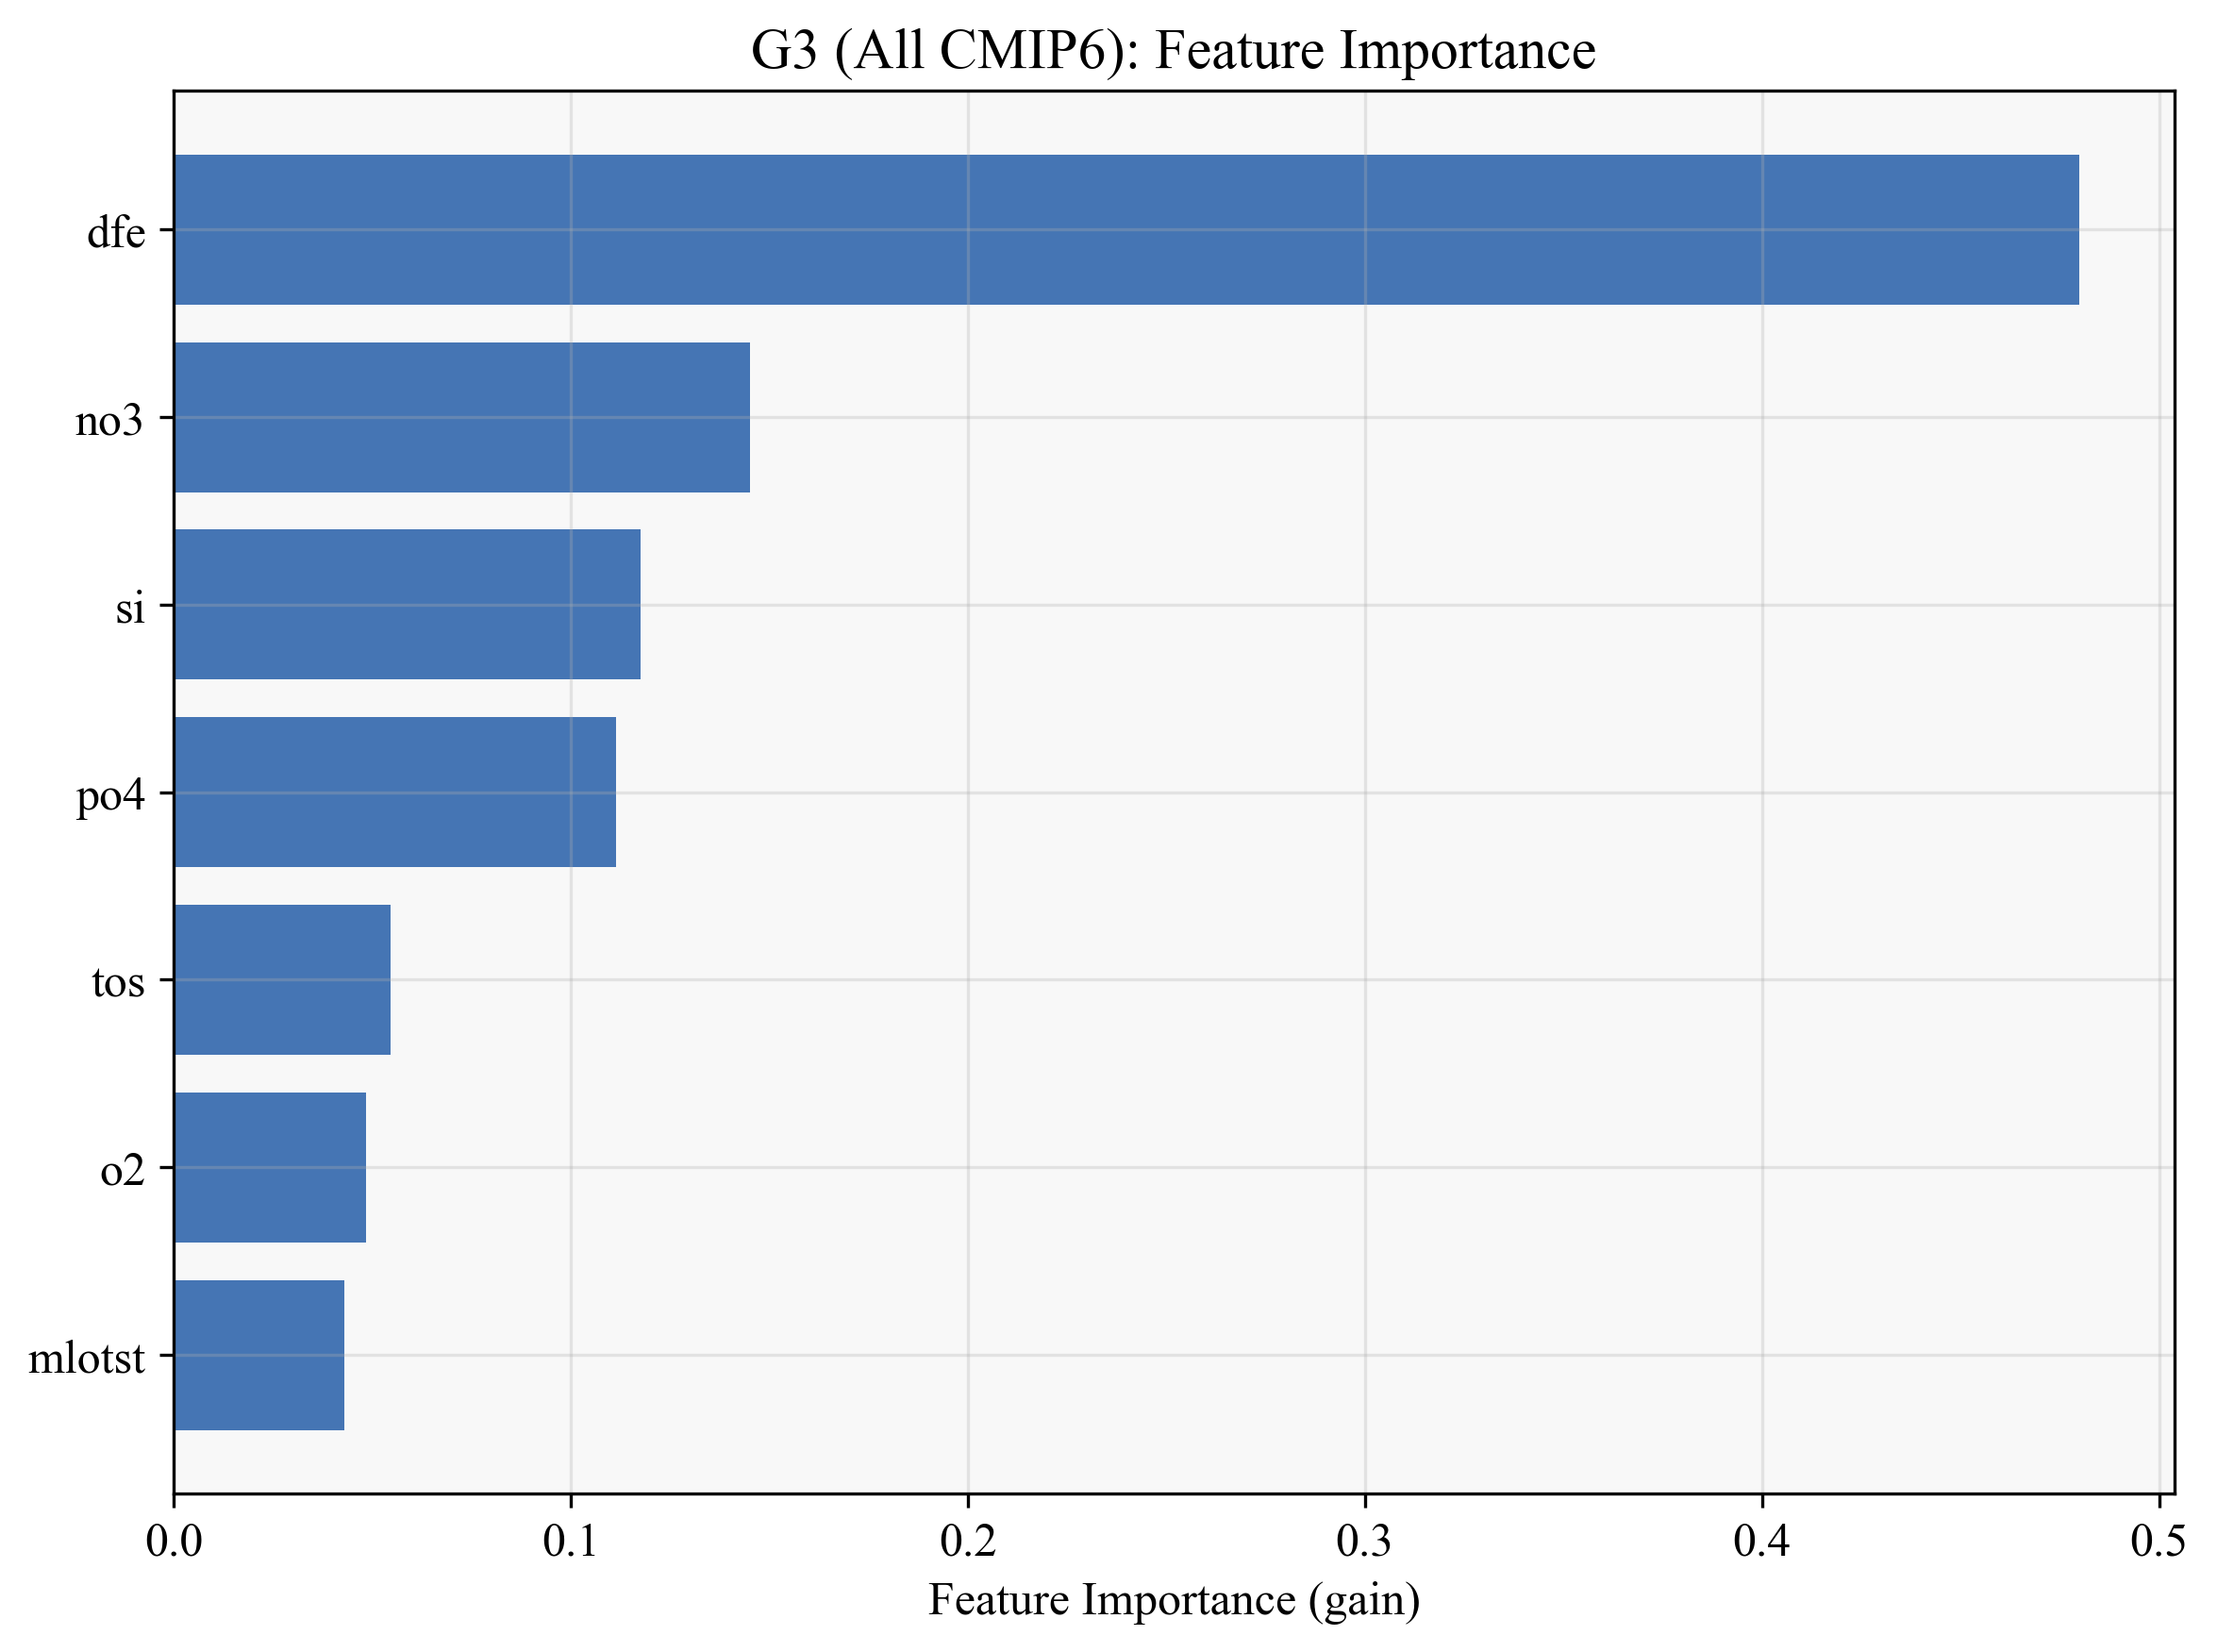

In [5]:
results_df = pd.DataFrame(all_results).T
results_df.index.name = "Model"
print(results_df.round(4).to_string())
results_df.to_csv(PROCESSED_DIR / "sklearn_cmip6_results.csv")
print(f"\nSaved to {PROCESSED_DIR / 'sklearn_cmip6_results.csv'}")


g3_keys = [k for k in all_results if k.startswith("G3_All")]
best_g3_key = max(g3_keys, key=lambda k: all_results[k]["R2"])
best_model_name = best_g3_key.split("/")[1]
best_search = all_searches[best_g3_key]
best_estimator = search.best_estimator_ if best_model_name != "Ridge" \
                 else best_search.best_estimator_
print(f"\nFeature Importance using: {best_g3_key} (R2={all_results[best_g3_key]['R2']:.4f})")
sub_g3 = df.dropna(subset=ALL_COLS + [TARGET_COL])
train_g3 = sub_g3[sub_g3["split"] == "train"]
X_g3 = train_g3[ALL_COLS].values.astype(np.float32)
y_g3 = train_g3[TARGET_COL].values.astype(np.float32)

scaler_g3 = StandardScaler()
X_g3_sc = scaler_g3.fit_transform(X_g3)

best_xgb_params = all_results.get("G3_All/XGB", {})
xgb_g3 = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=SEED, verbosity=0,
)
xgb_g3.fit(X_g3_sc, y_g3)
importance = xgb_g3.feature_importances_
sorted_idx = np.argsort(importance)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([ALL_COLS[i] for i in sorted_idx], importance[sorted_idx], color="#4575b4")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("G3 (All CMIP6): Feature Importance")
fig.tight_layout()
plt.show()
p = FIGURES_DIR / "fig_feature_importance_cmip6.png"
fig.savefig(p, dpi=300, bbox_inches="tight")

  Best for G1_Physics: G1_Physics/RF (R2=0.1404)
  Best for G2_Nutrients: G2_Nutrients/RF (R2=0.6865)
  Best for G3_All: G3_All/XGB (R2=0.6969)


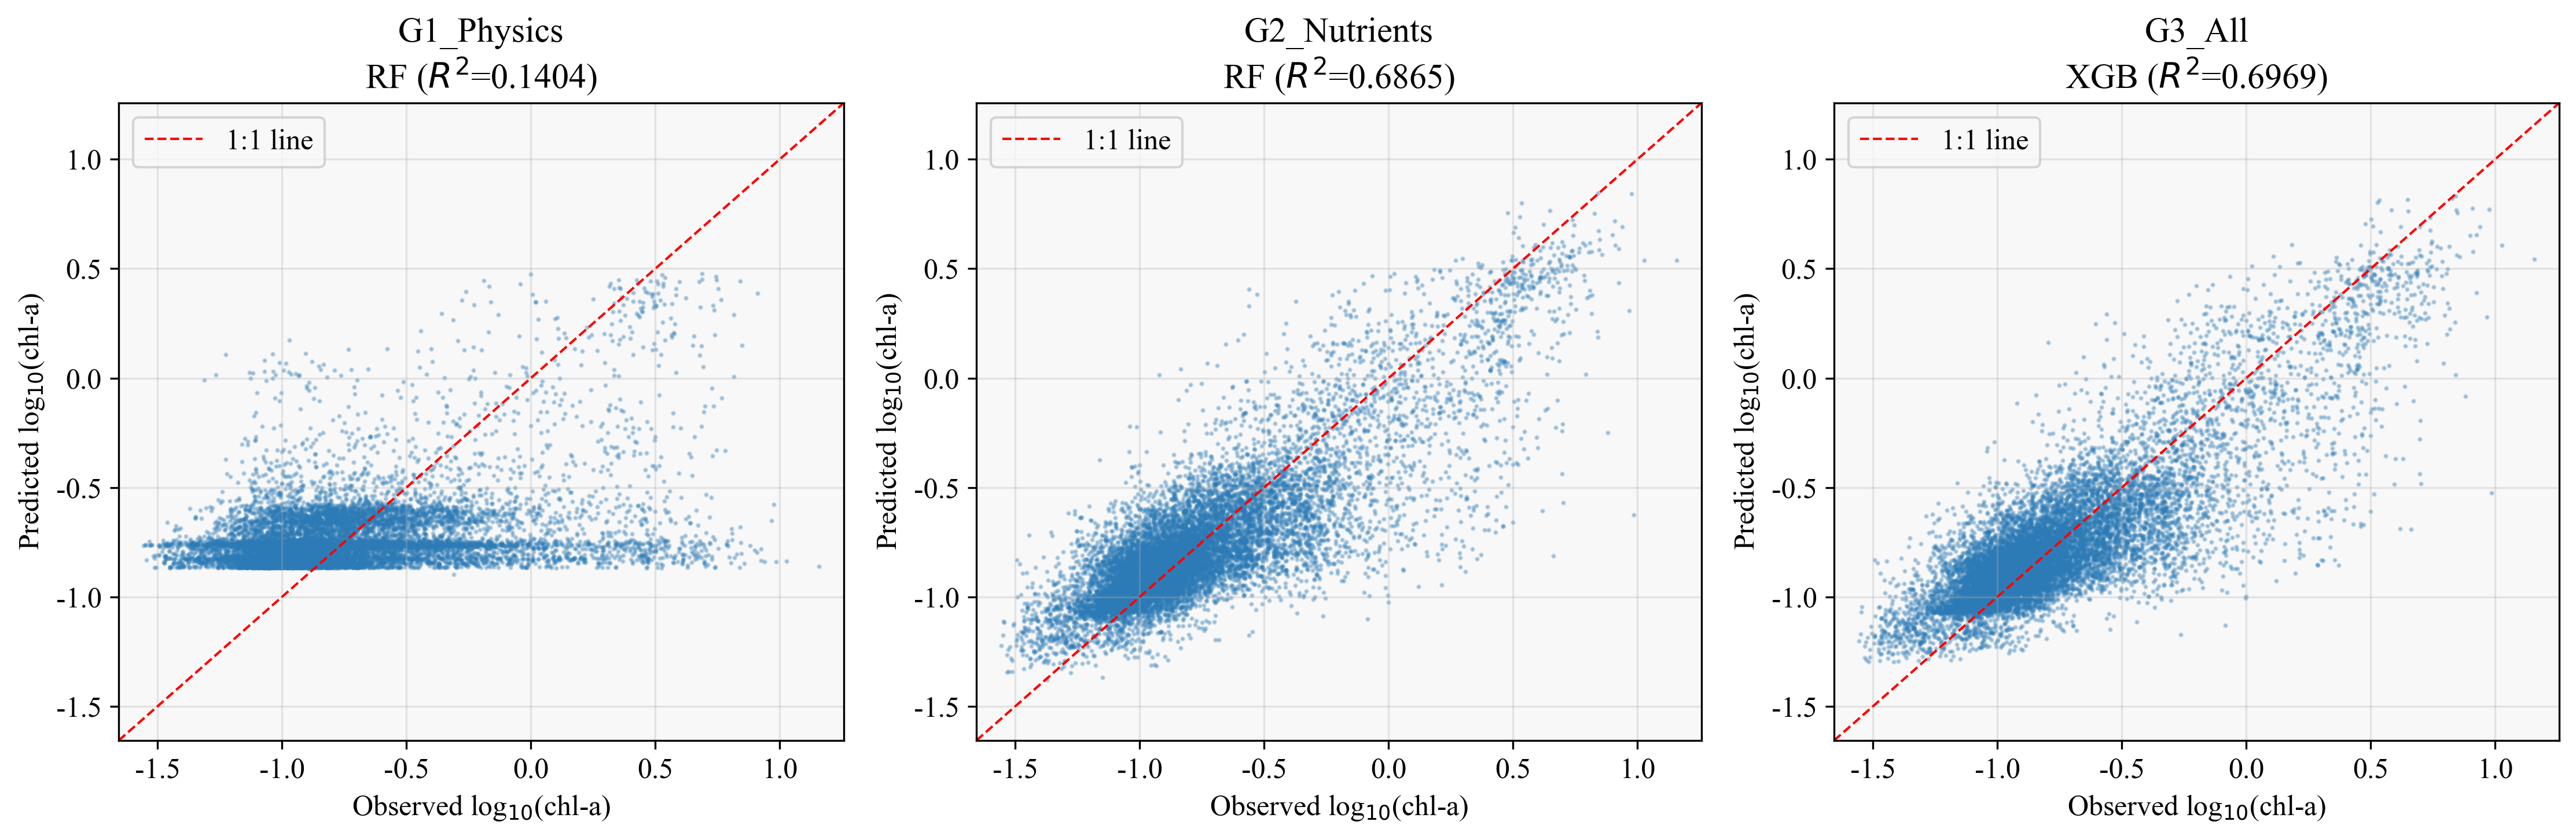

In [6]:
best_per_group = {}
for gname in GROUPS.keys():
    best_key = max(
        [k for k in all_results if k.startswith(gname)],
        key=lambda k: all_results[k]["R2"],
    )
    best_per_group[gname] = best_key
    print(f"  Best for {gname}: {best_key} (R2={all_results[best_key]['R2']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (gname, key) in zip(axes, best_per_group.items()):
    y_t, y_p = all_preds[key]
    ax.scatter(y_t, y_p, s=1, alpha=0.3, c="#2c7bb6")
    lims = [min(y_t.min(), y_p.min()) - 0.1,
            max(y_t.max(), y_p.max()) + 0.1]
    ax.plot(lims, lims, "r--", lw=1, label="1:1 line")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Observed log$_{10}$(chl-a)")
    ax.set_ylabel("Predicted log$_{10}$(chl-a)")
    r2 = all_results[key]["R2"]
    ax.set_title(f"{gname}\n{key.split('/')[1]} ($R^2$={r2:.4f})")
    ax.legend()
fig.tight_layout()
plt.show()
p = FIGURES_DIR / "fig_scatter_best_cmip6.png"
fig.savefig(p, dpi=300, bbox_inches="tight")